In [117]:
import os
from glob import glob
import torch
import shutil
from tqdm import tqdm
import numpy as np
import nibabel
from monai.transforms import (
    Compose,
    LoadImaged,
    ToTensord,
    EnsureChannelFirstD,
    Resized,
    ToTensord,
    Spacingd,
    Orientationd,
    ScaleIntensityRanged,
    CropForegroundd,
    ResizeWithPadOrCropd
)
from monai.data import Dataset, DataLoader,CacheDataset
from monai.utils import set_determinism
from monai.utils import first
import matplotlib.pyplot as plt


In [123]:
def prepare2(in_dir, pixdim=(1.5, 1.5, 2.0), a_min=0, a_max=1327, spatial_size=(256, 256, 128), cache=False):
    
    set_determinism(seed=0)

    train_volumes = sorted(glob(os.path.join(in_dir,'TrainVolume', '*.nii.gz')))
    train_labels = sorted(glob(os.path.join(in_dir,'TrainSegmentation', '*.nii.gz')))

    test_volumes = sorted(glob(os.path.join(in_dir,'TestVolume', '*.nii.gz')))
    test_labels = sorted(glob(os.path.join(in_dir,'TestSegmentation', '*.nii.gz')))

    #print(train_labels)
    #print(train_volumes)

    #print(test_labels)
    #print(test_volumes)

    train_files = [{"image": image_name, "label": label_name}for image_name, label_name in zip(train_volumes, train_labels) ]
    test_files = [{"image": image_name, "label": label_name}for image_name, label_name in zip(test_volumes, test_labels) ]

    print(train_files)
    print(test_files)

    # load the images
    # do any transforms
    # convert them to torch tensors it must be last step


    train_transforms = Compose([

        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstD(keys=["image", "label"]),
        Spacingd(keys=["image", "label"], pixdim=pixdim),
        ScaleIntensityRanged(
            keys=["image"],
            a_min=0,
            a_max=1327,
            b_min=0.0,
            b_max=1.0,
            clip=True,
        
        ),
        CropForegroundd(keys=["image", "label"], source_key="image"),
        ResizeWithPadOrCropd(keys=["image", "label"], spatial_size=spatial_size),
        ToTensord(keys=["image", "label"])

        
    ])

    test_transforms = Compose([

        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstD(keys=["image", "label"]),
        Spacingd(keys=["image", "label"], pixdim=pixdim),
        ScaleIntensityRanged(
            keys=["image"],
            a_min=0,
            a_max=1327,
            b_min=0.0,
            b_max=1.0,
            clip=True,
        
        ),
        CropForegroundd(keys=["image", "label"], source_key="image"),
        ResizeWithPadOrCropd(keys=["image", "label"], spatial_size=spatial_size),
        ToTensord(keys=["image", "label"])

        
    ])

    if cache:
        train_ds = CacheDataset(data=train_files, transform=train_transforms, cache_rate=1.0)
        train_loader = DataLoader(train_ds, batch_size=1,)

        test_ds = CacheDataset(data=test_files, transform=test_transforms, cache_rate=1.0)
        test_loader = DataLoader(test_ds, batch_size=1,)

        return train_loader, test_loader
    
    else:
        train_ds = Dataset(data=train_files, transform=train_transforms)
        train_loader = DataLoader(train_ds, batch_size=1,)

        test_ds = Dataset(data=test_files, transform=test_transforms)
        test_loader = DataLoader(test_ds, batch_size=1,)

        return train_loader, test_loader






In [133]:
def show_patient(data,Slice_Number=1,train = True, test = False):

    check_patient_train, check_patient_test = data

    view_train_patient = first(check_patient_train)
    view_test_patient = first(check_patient_test)


    if train:
       # train_iter = iter(check_patient_train)
        #for _ in range(4):  # İlk 4 hastayı atla
            #next(train_iter)
        #view_train_patient = next(train_iter)  # 5. hastayı al
        
        
        plt.figure('Visualization Train' , (12,6))
        plt.subplot(1,2,1)
        plt.title(f"image {Slice_Number}")
        plt.imshow(view_train_patient ['image'][0, 0, :, :,Slice_Number], cmap='gray')

        plt.subplot(1,2,2)
        plt.title(f"label {Slice_Number}")
        plt.imshow(view_train_patient['label'][0, 0,:, :, Slice_Number])
        plt.show()

    if test:
        #test_iter = iter(check_patient_test)
        #for _ in range(4):  # İlk 4 hastayı atla
            #next(test_iter)
        #view_test_patient = next(test_iter)  # 5. hastayı al

        plt.figure('Visualization Test' , (12,6))
        plt.subplot(1,2,1)
        plt.title(f"image {Slice_Number}")
        plt.imshow(view_test_patient ['image'][0, 0, :, :, Slice_Number], cmap='gray')

        plt.subplot(1,2,2)
        plt.title(f"label {Slice_Number}")
        plt.imshow(view_test_patient['label'][0, 0,:, :, Slice_Number])
        plt.show()

[{'image': 'D:/BrainDataset\\TrainVolume\\BRATS_001.nii.gz', 'label': 'D:/BrainDataset\\TrainSegmentation\\BRATS_001.nii.gz'}, {'image': 'D:/BrainDataset\\TrainVolume\\BRATS_002.nii.gz', 'label': 'D:/BrainDataset\\TrainSegmentation\\BRATS_002.nii.gz'}, {'image': 'D:/BrainDataset\\TrainVolume\\BRATS_003.nii.gz', 'label': 'D:/BrainDataset\\TrainSegmentation\\BRATS_003.nii.gz'}, {'image': 'D:/BrainDataset\\TrainVolume\\BRATS_004.nii.gz', 'label': 'D:/BrainDataset\\TrainSegmentation\\BRATS_004.nii.gz'}, {'image': 'D:/BrainDataset\\TrainVolume\\BRATS_005.nii.gz', 'label': 'D:/BrainDataset\\TrainSegmentation\\BRATS_005.nii.gz'}, {'image': 'D:/BrainDataset\\TrainVolume\\BRATS_006.nii.gz', 'label': 'D:/BrainDataset\\TrainSegmentation\\BRATS_006.nii.gz'}, {'image': 'D:/BrainDataset\\TrainVolume\\BRATS_007.nii.gz', 'label': 'D:/BrainDataset\\TrainSegmentation\\BRATS_007.nii.gz'}, {'image': 'D:/BrainDataset\\TrainVolume\\BRATS_008.nii.gz', 'label': 'D:/BrainDataset\\TrainSegmentation\\BRATS_008.n

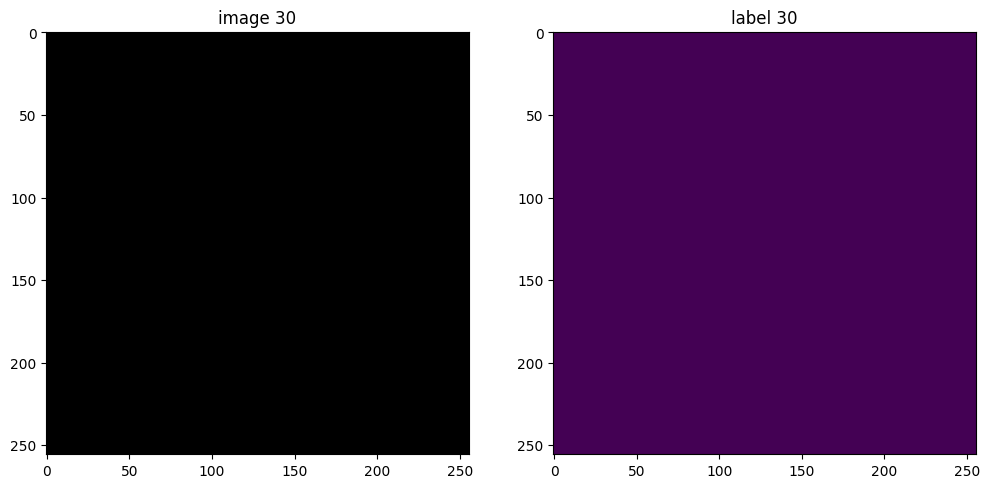

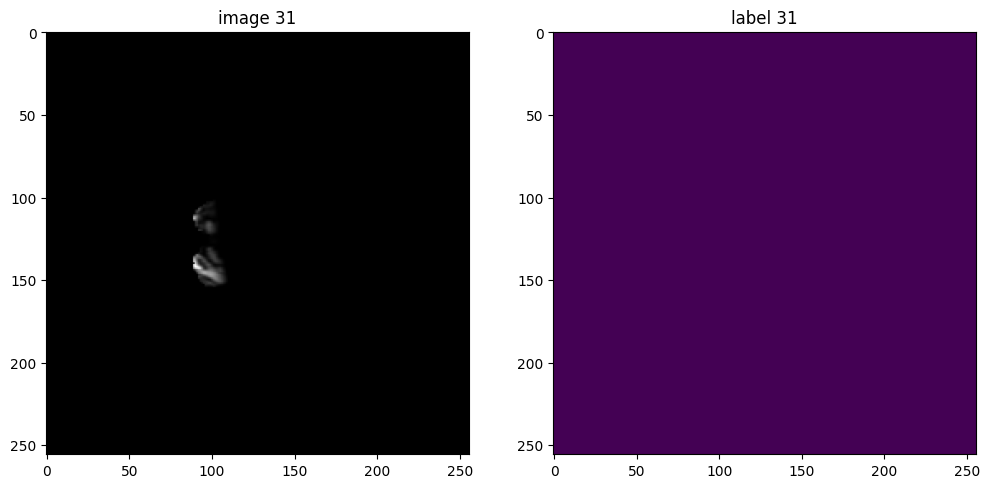

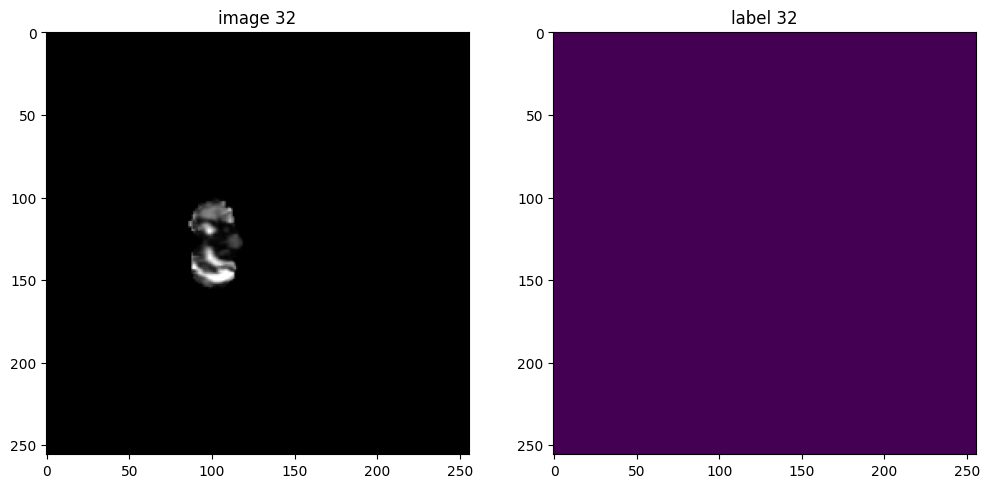

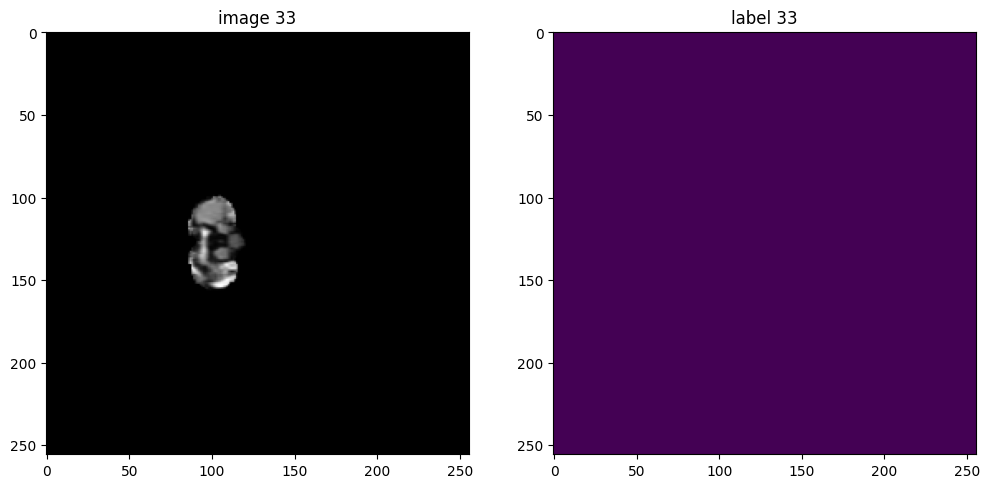

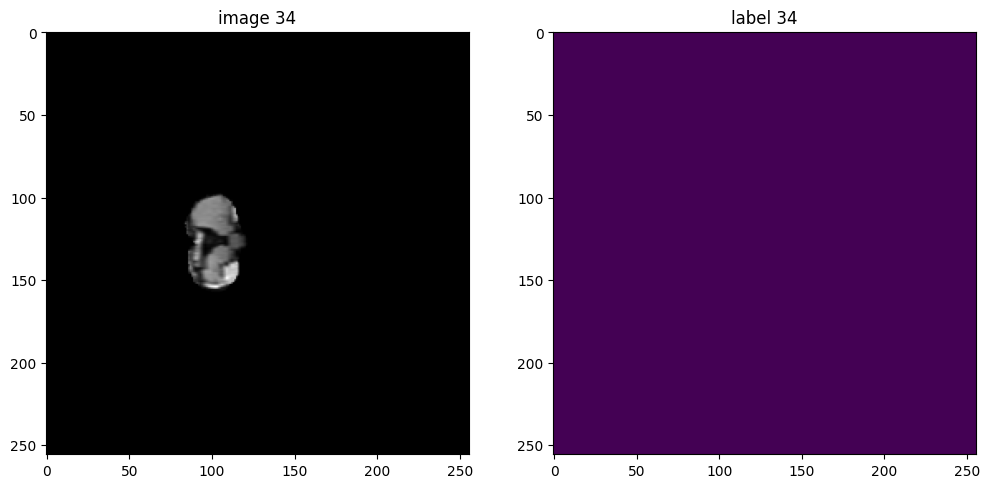

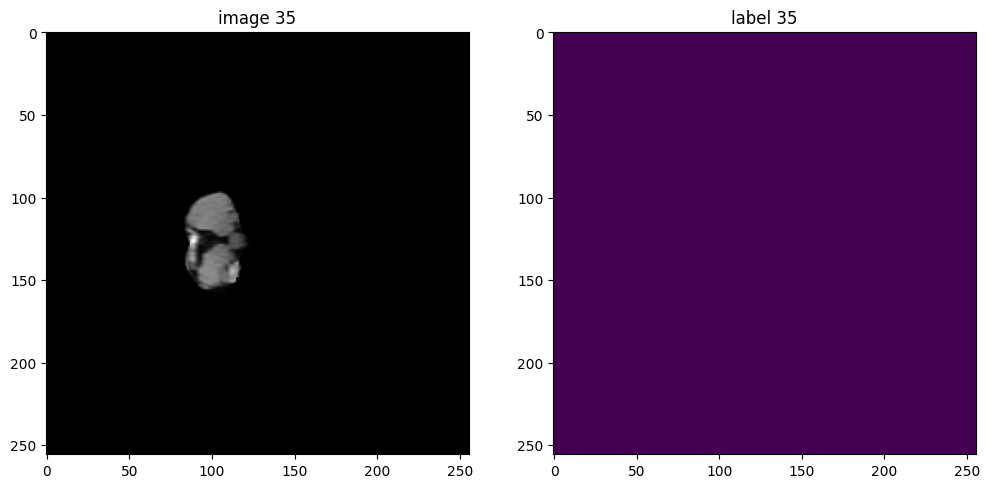

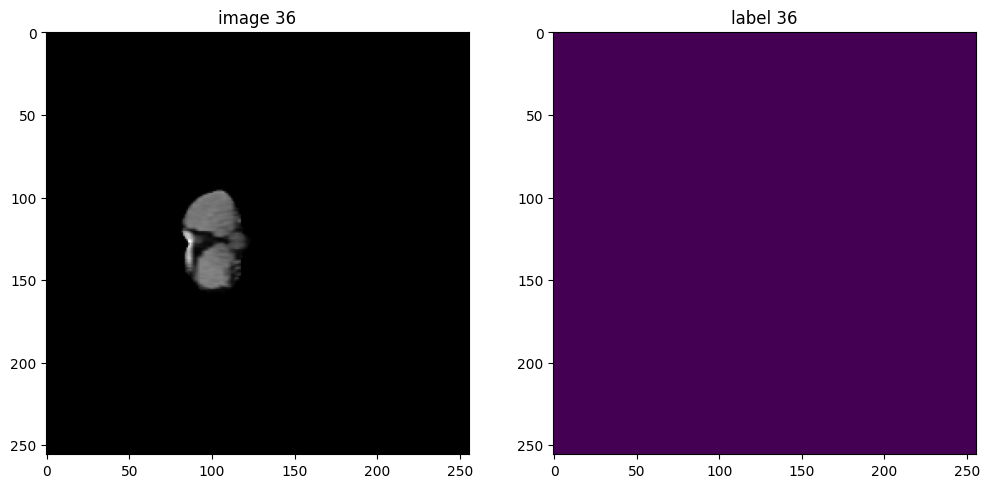

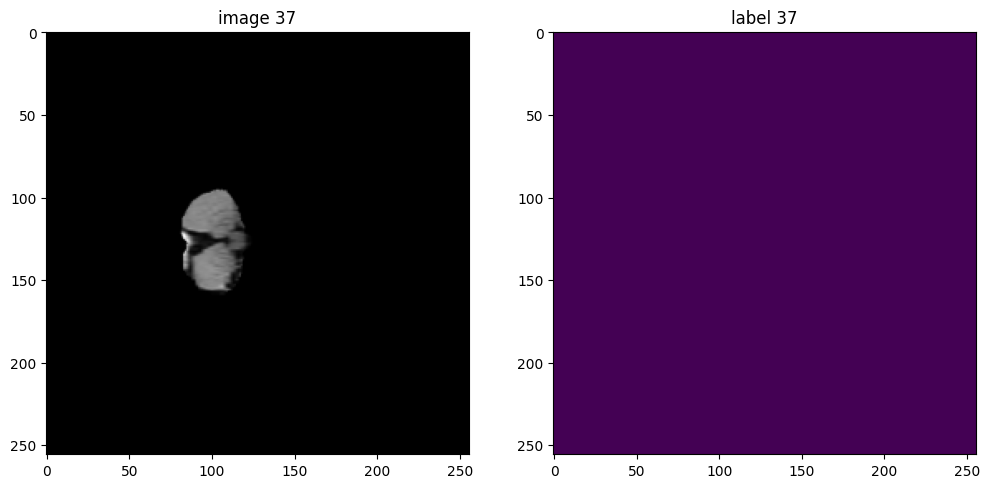

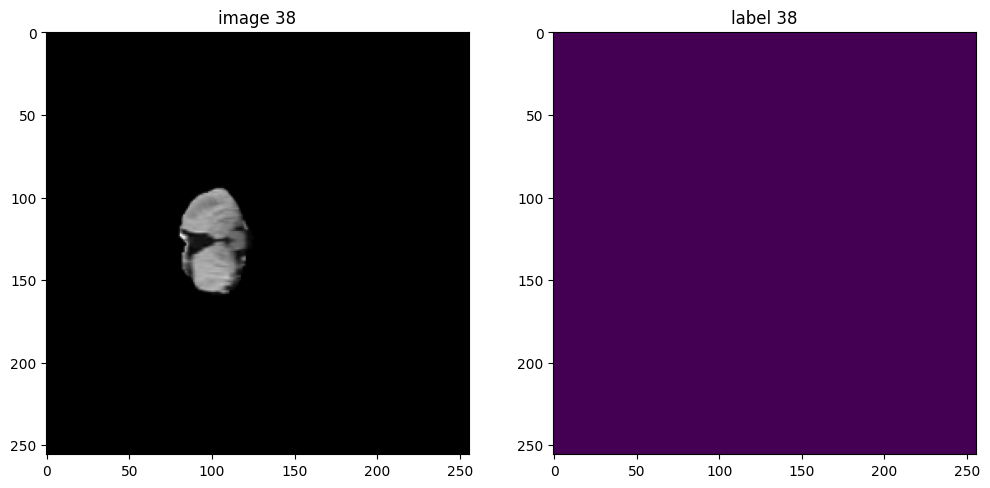

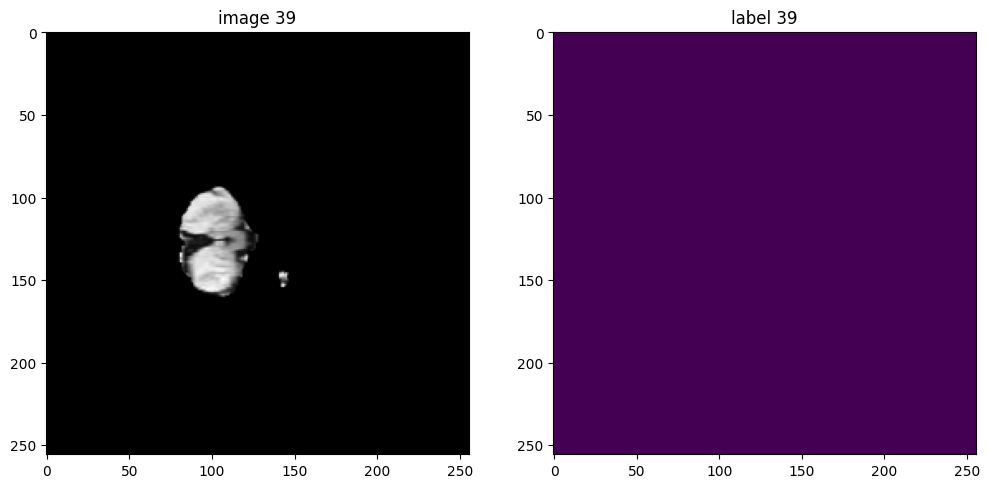

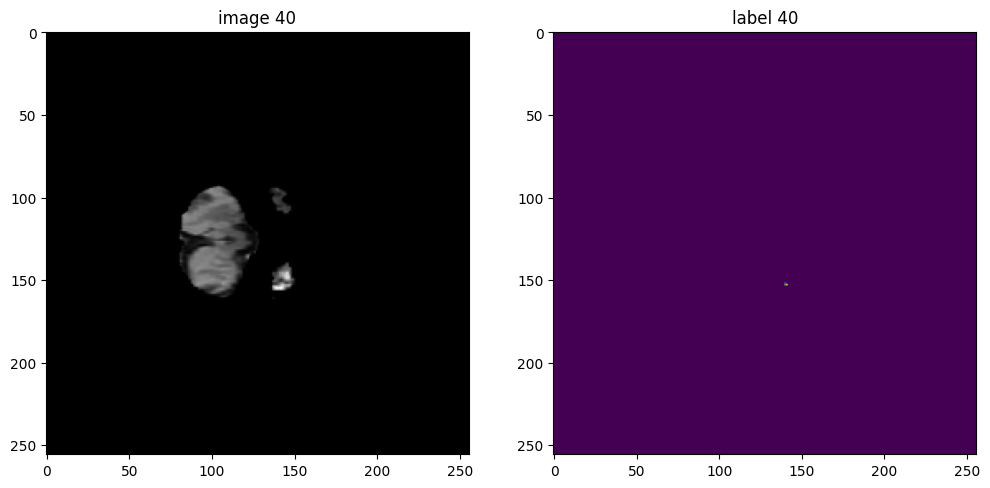

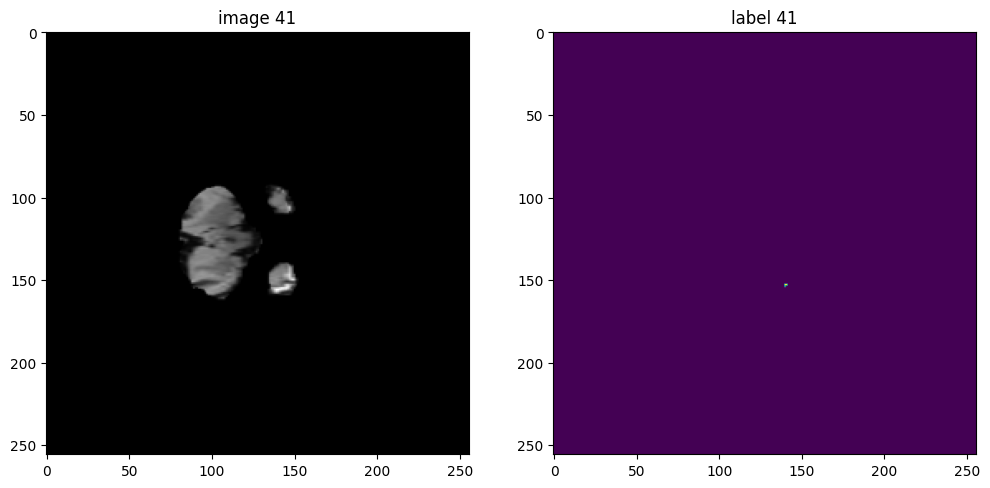

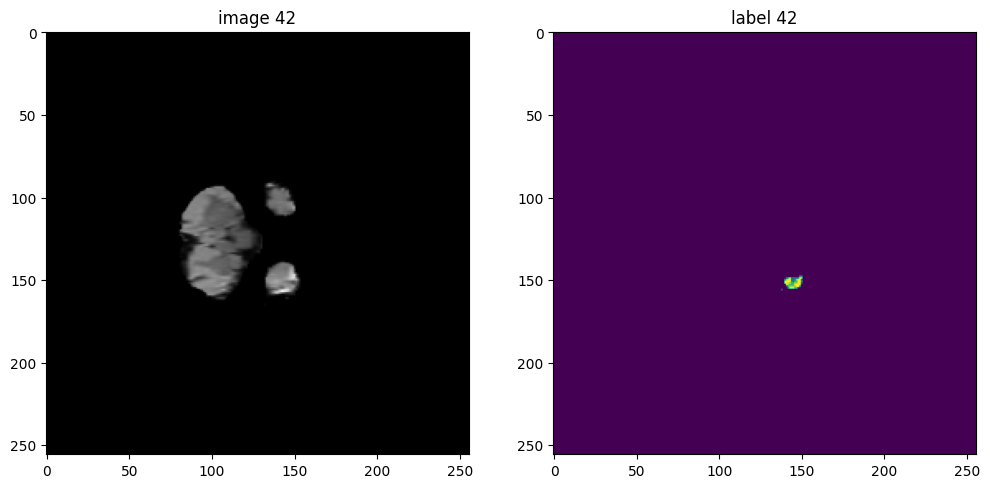

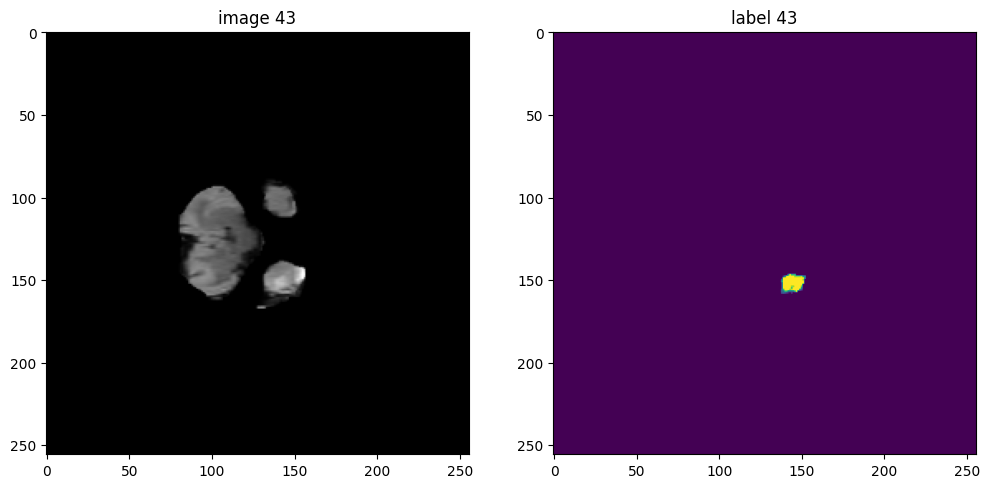

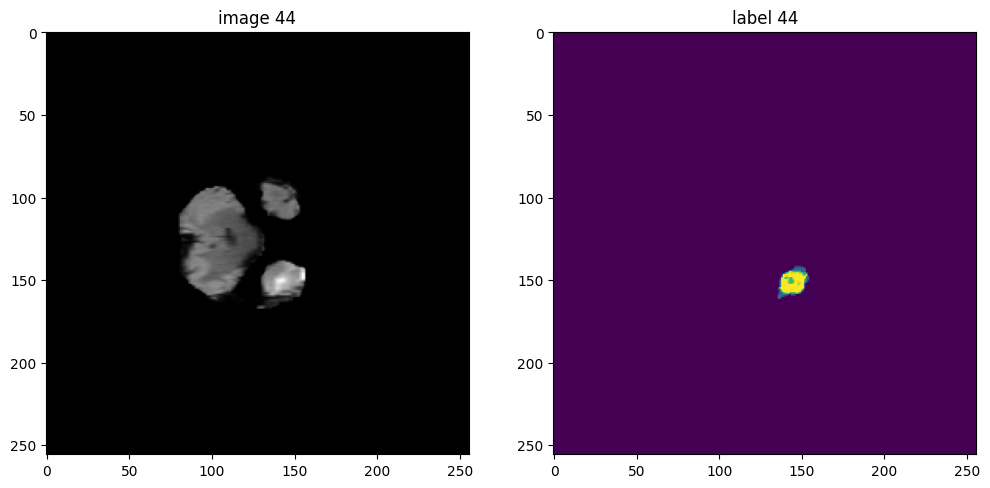

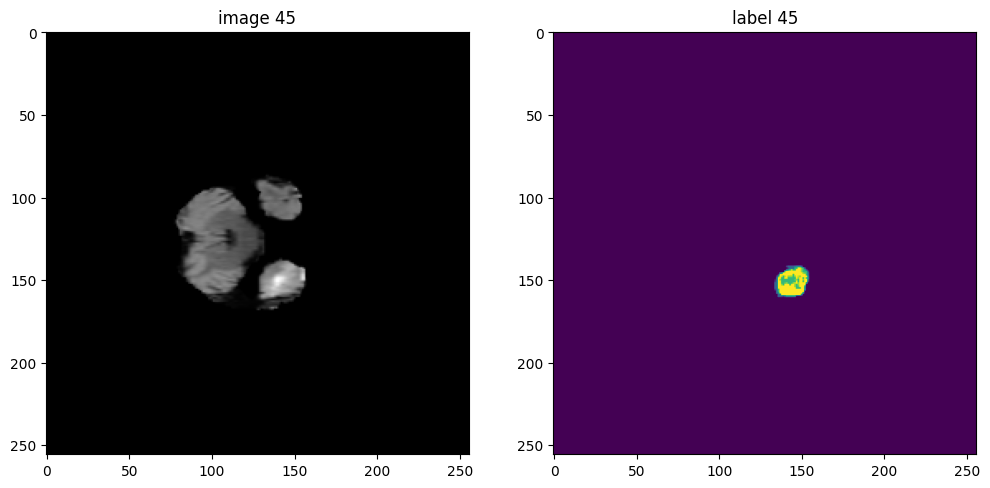

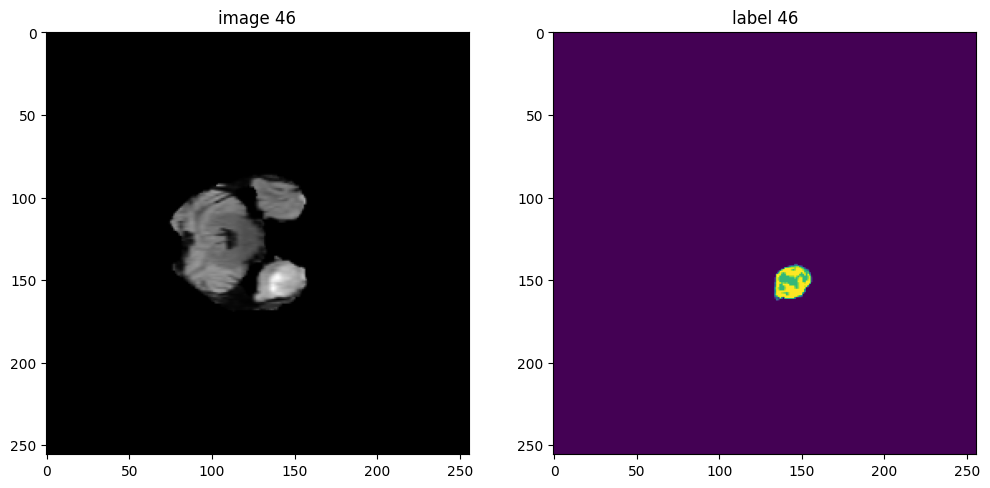

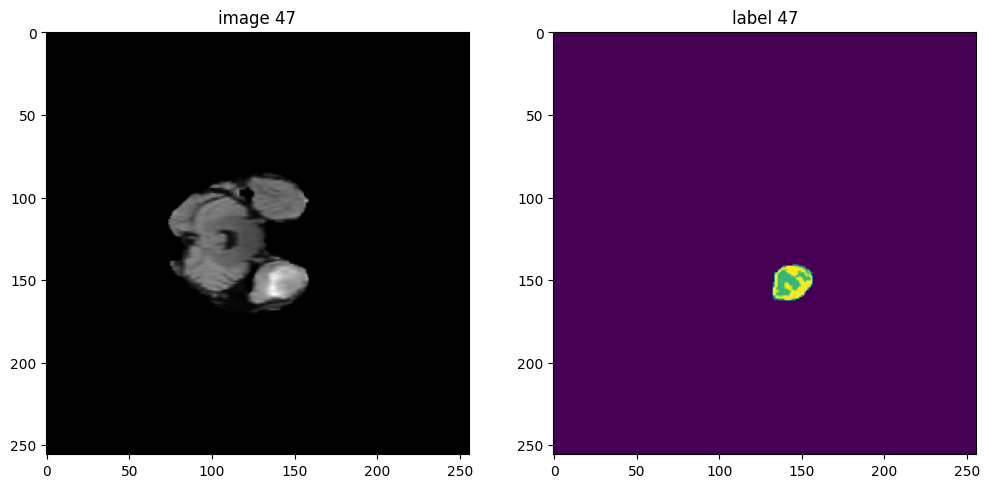

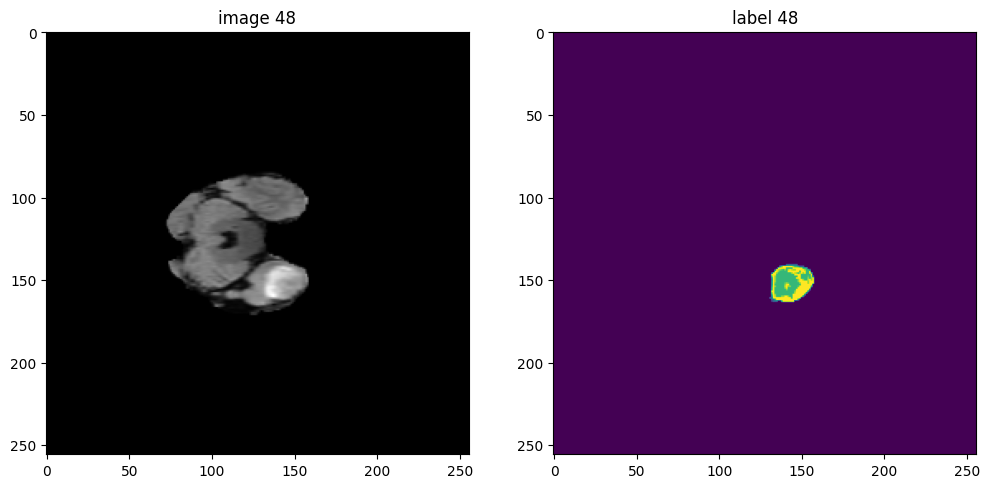

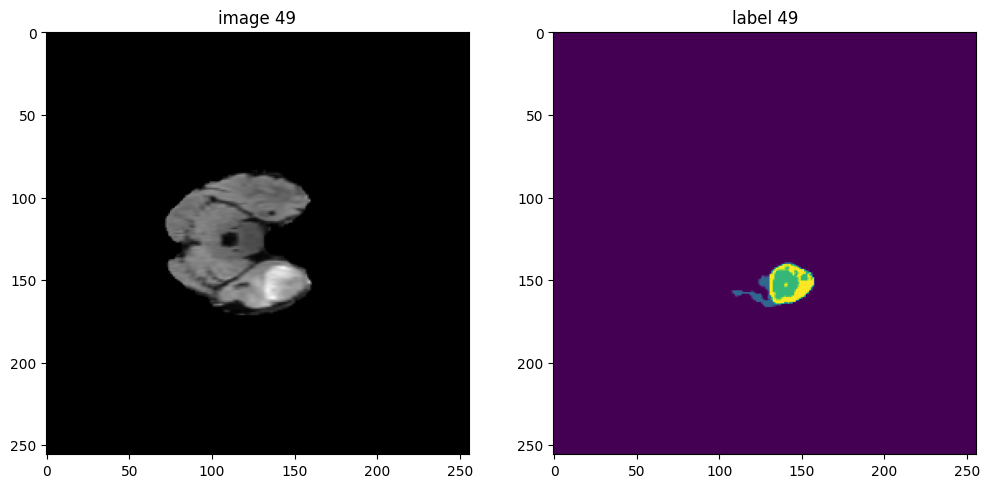

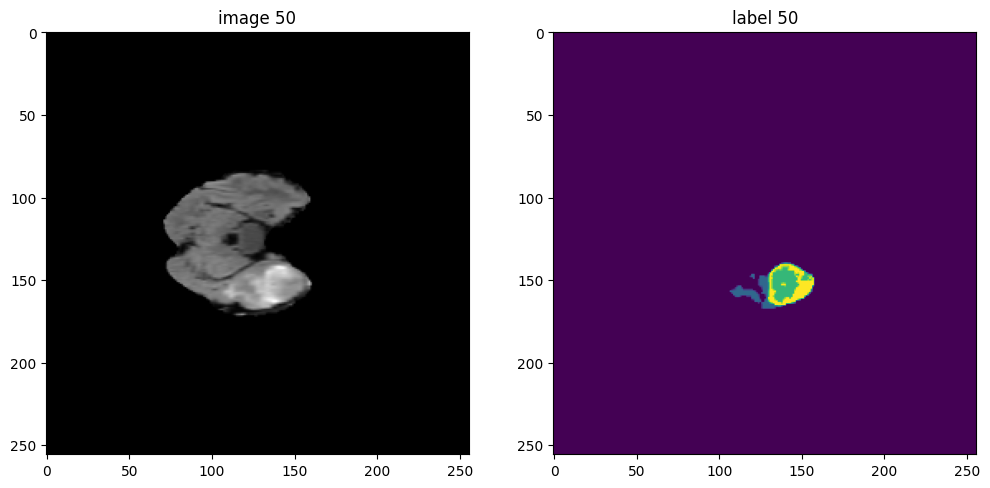

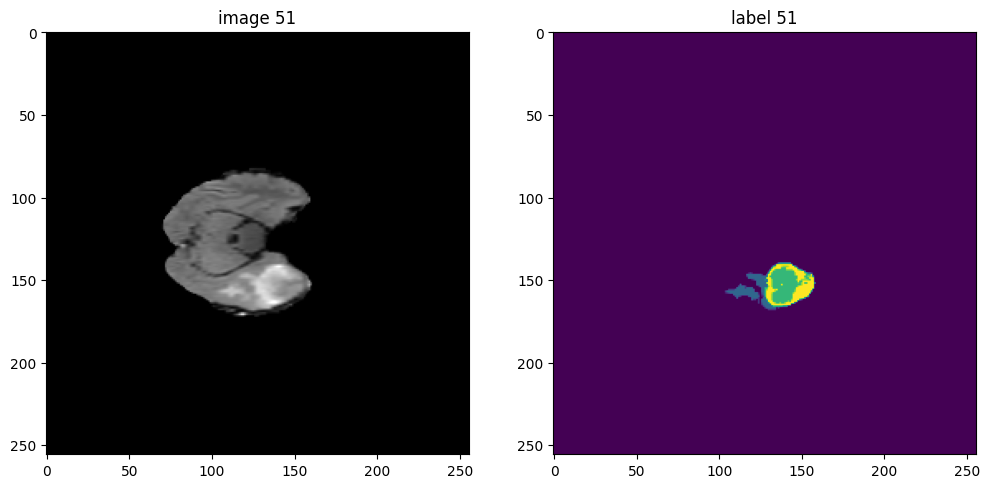

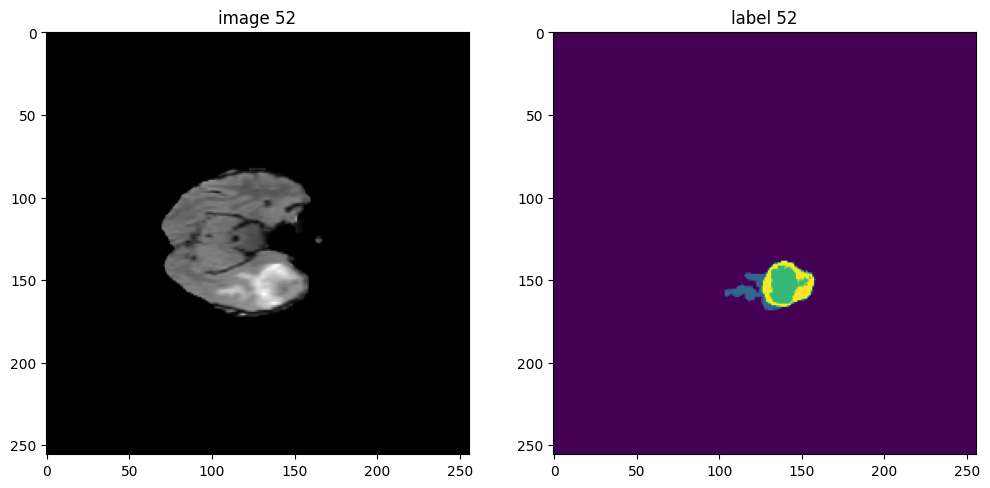

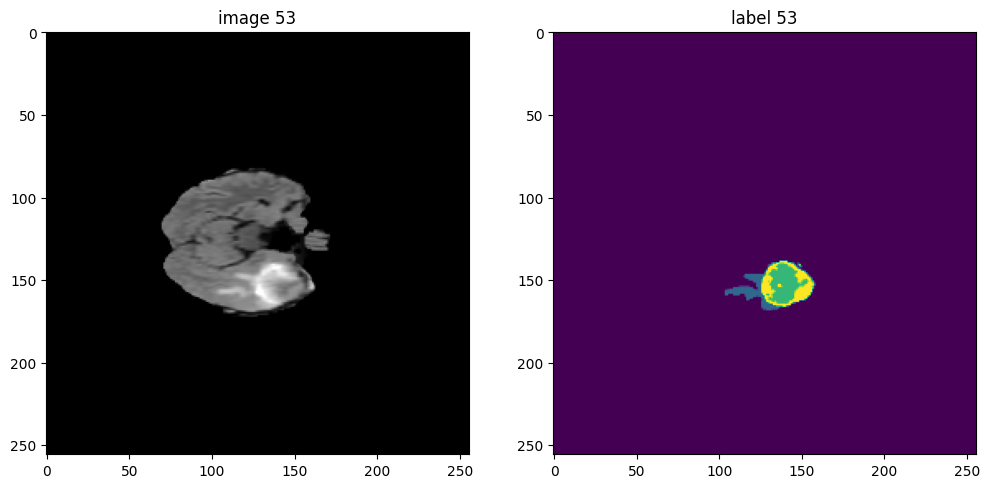

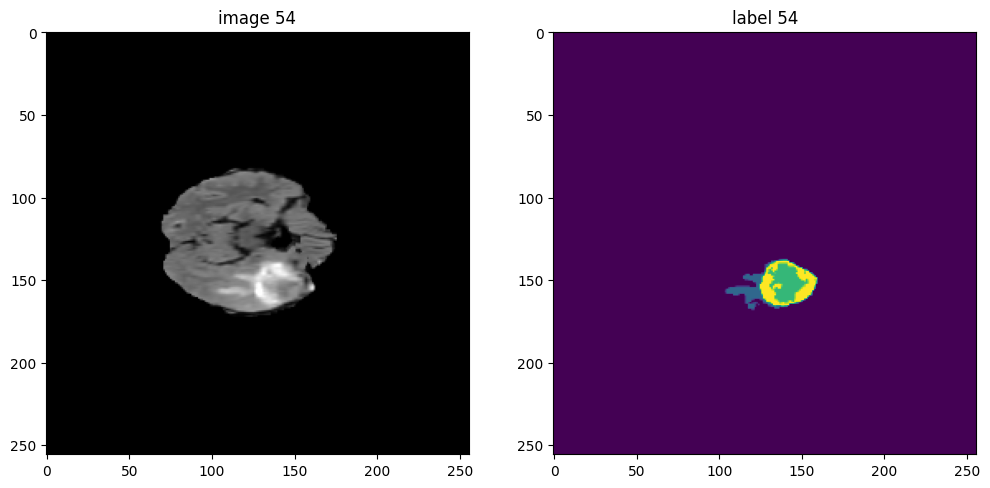

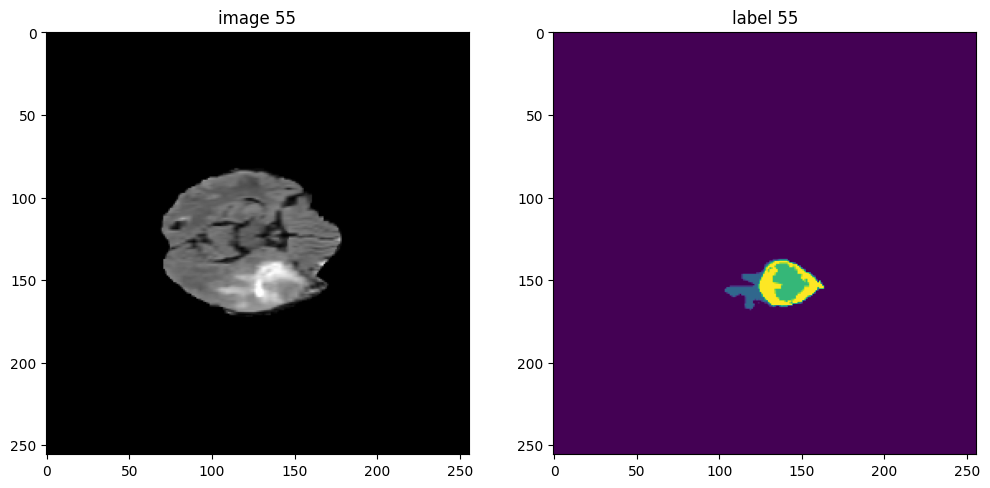

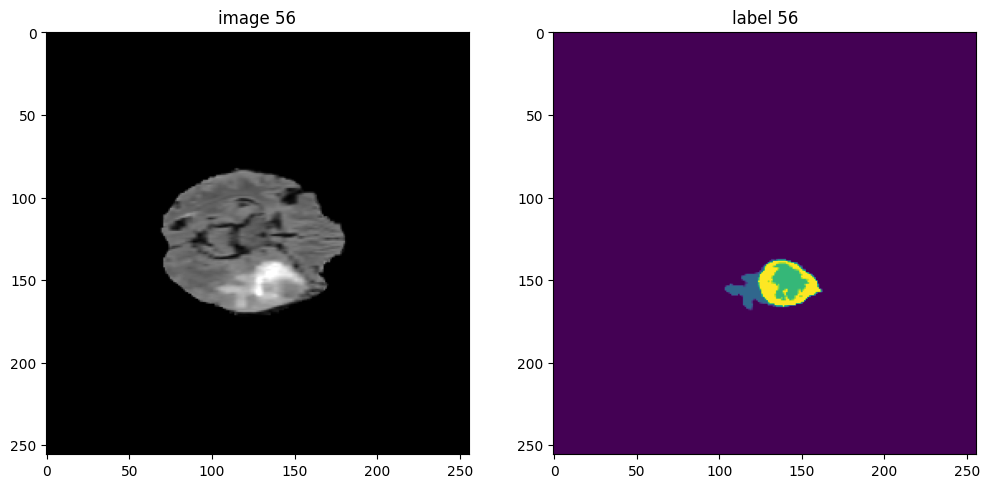

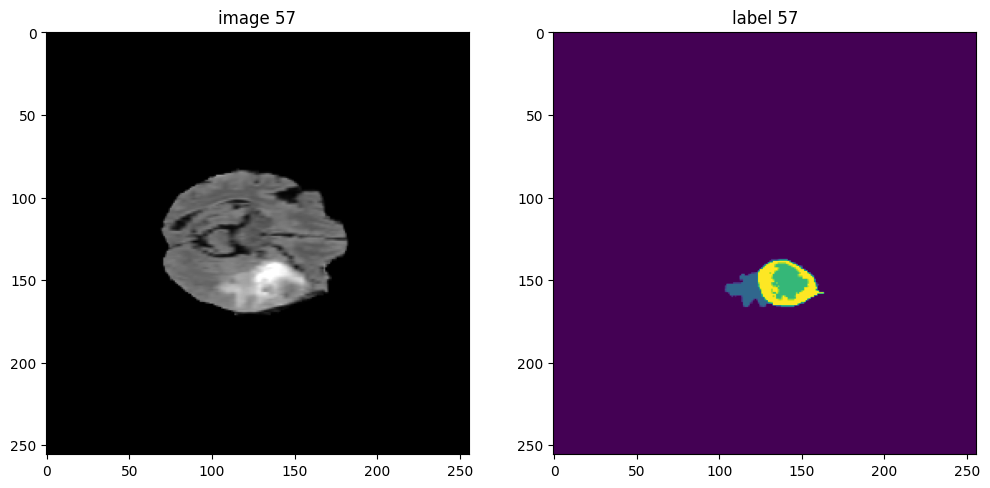

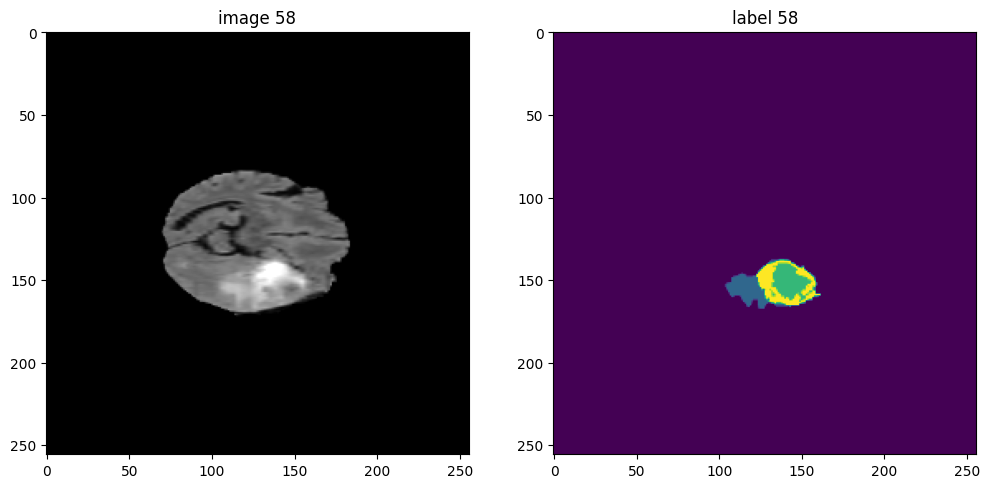

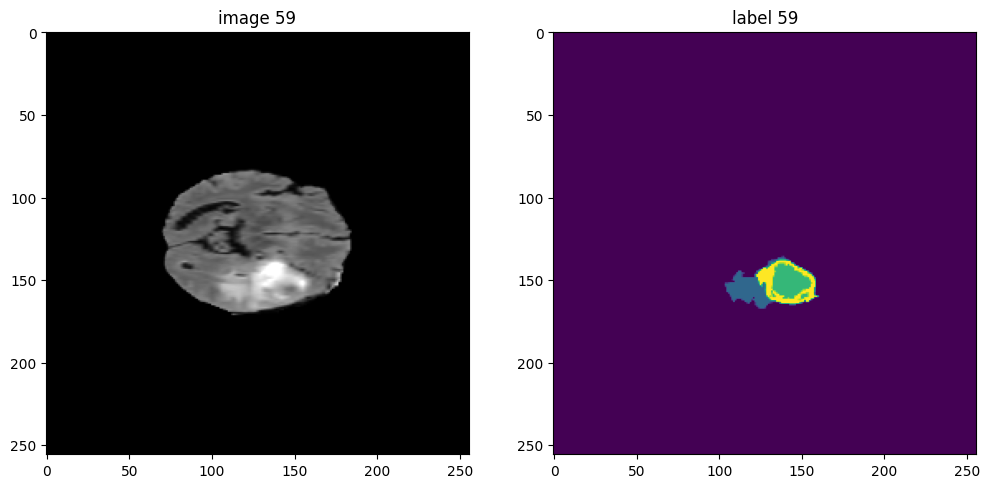

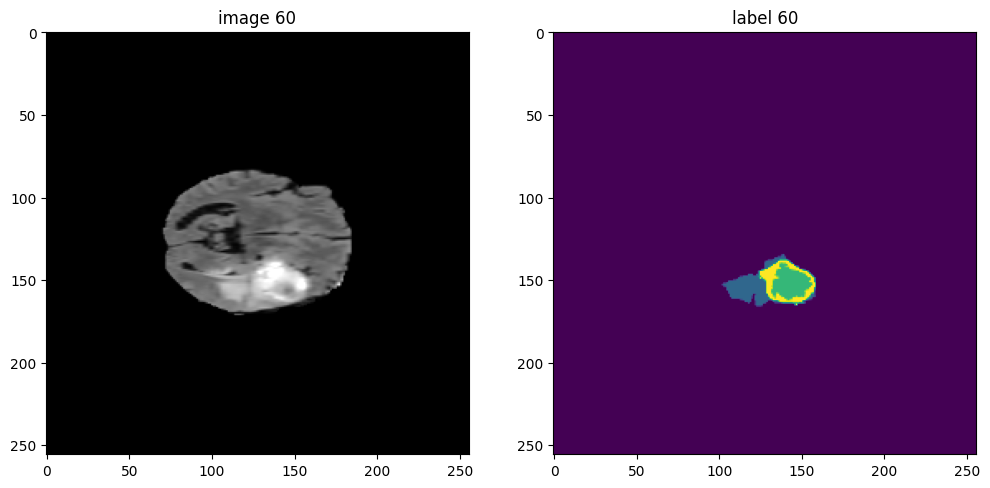

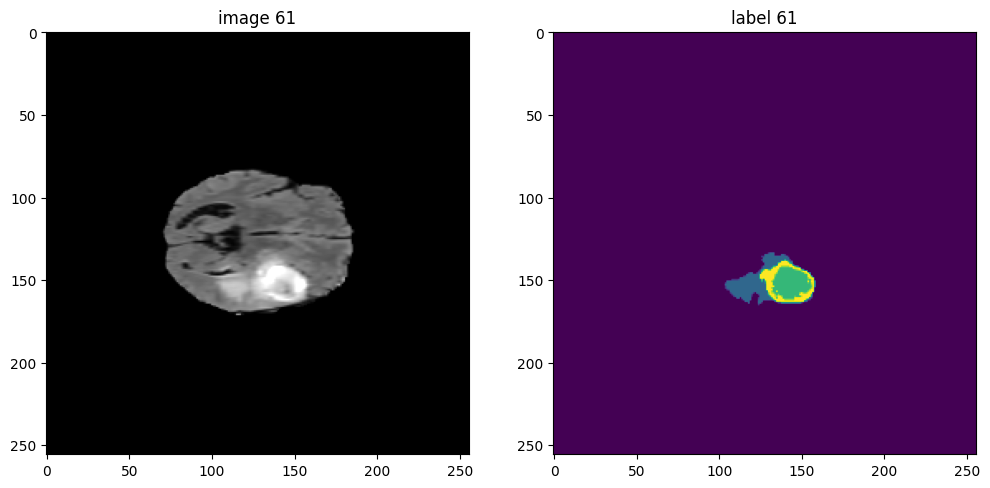

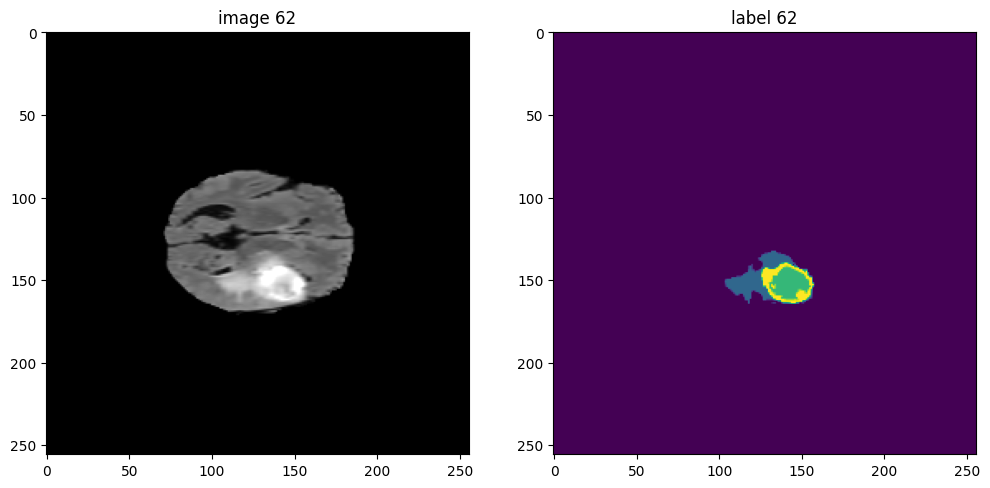

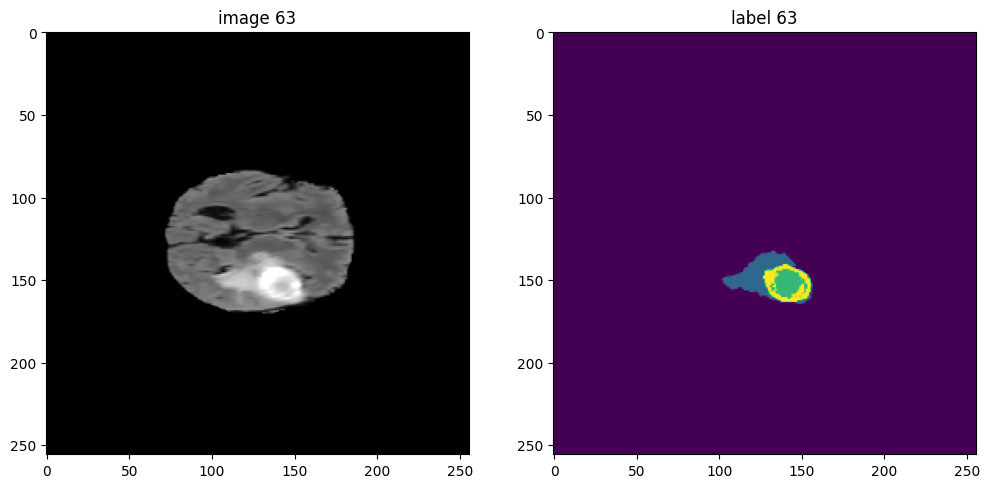

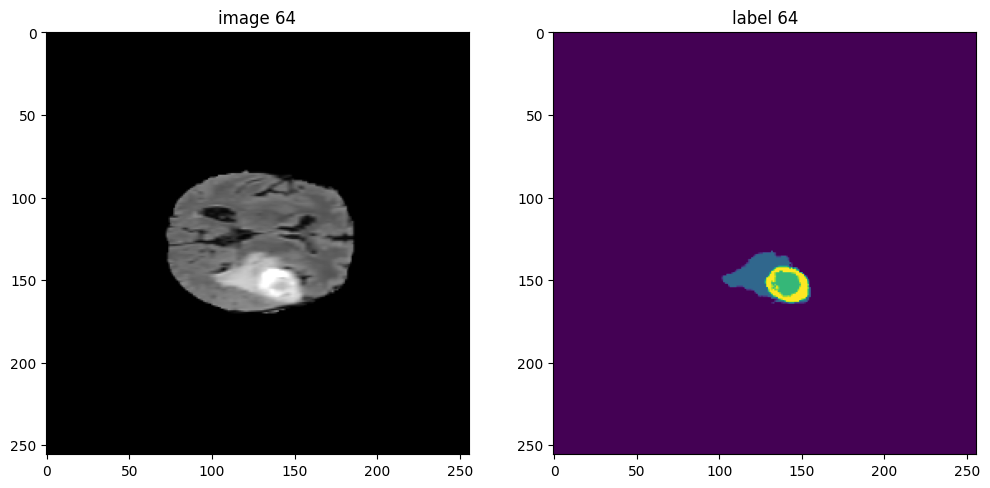

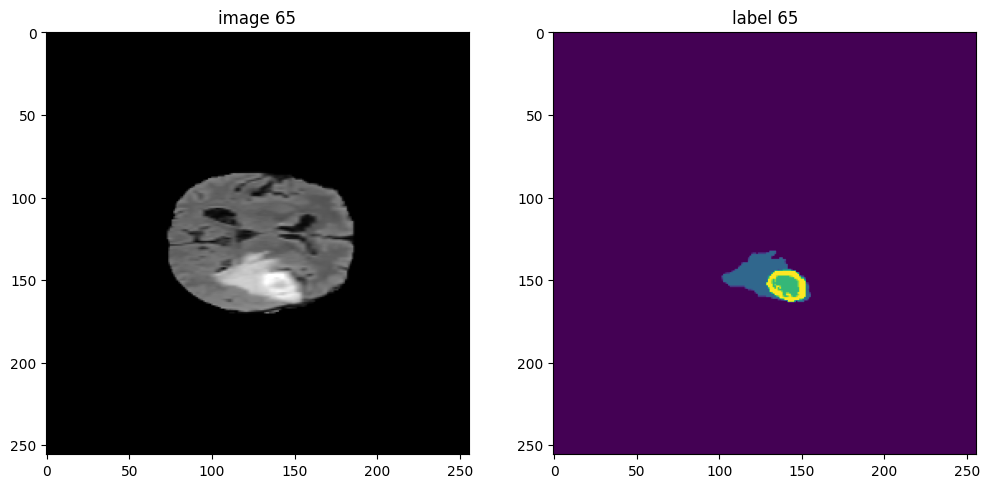

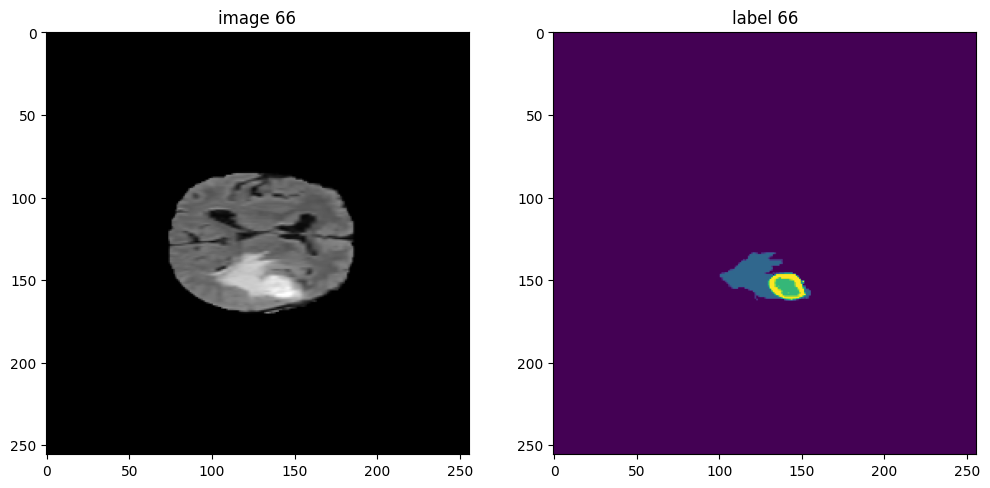

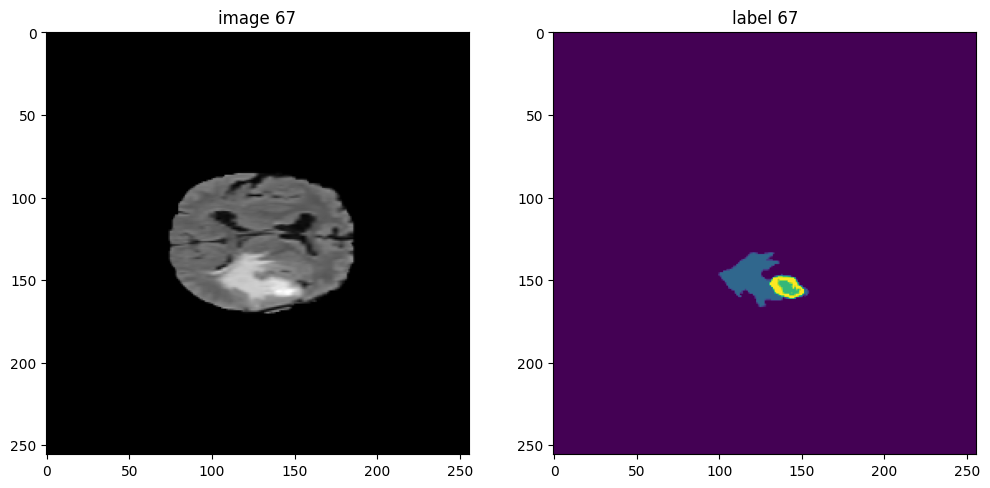

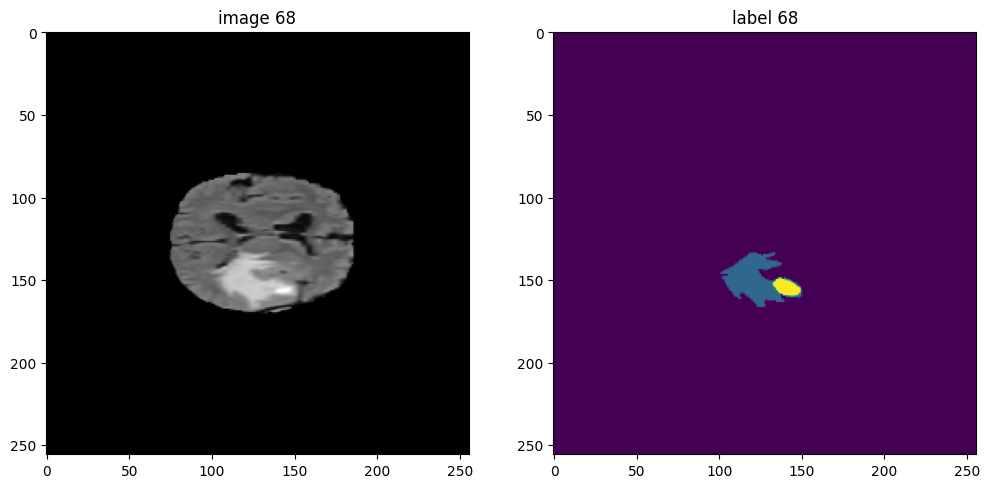

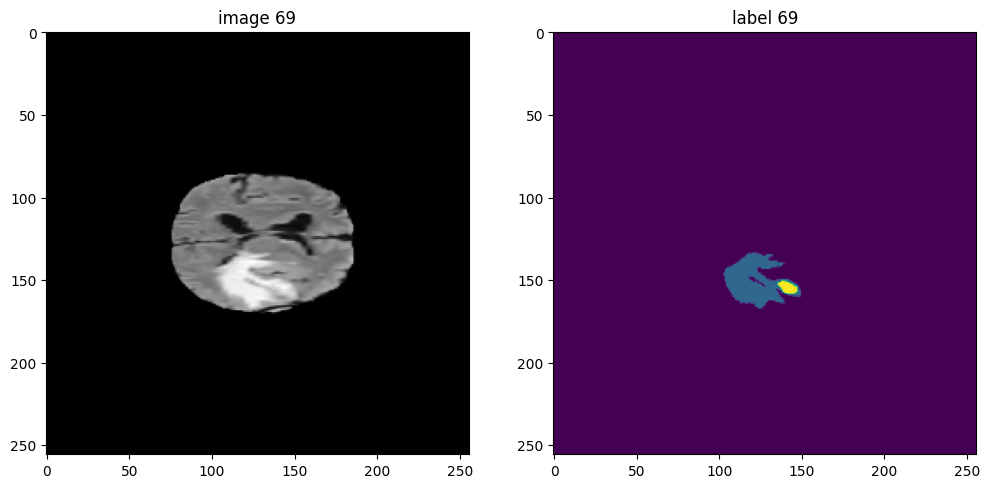

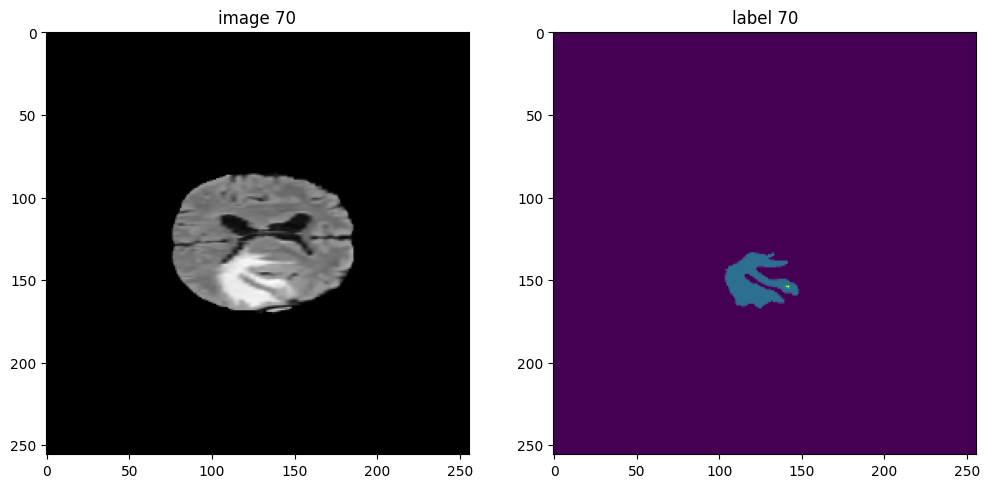

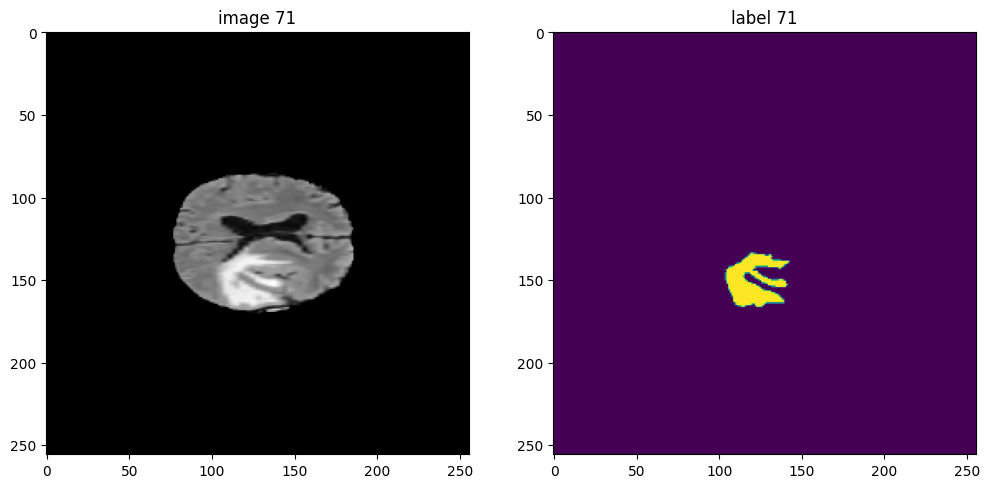

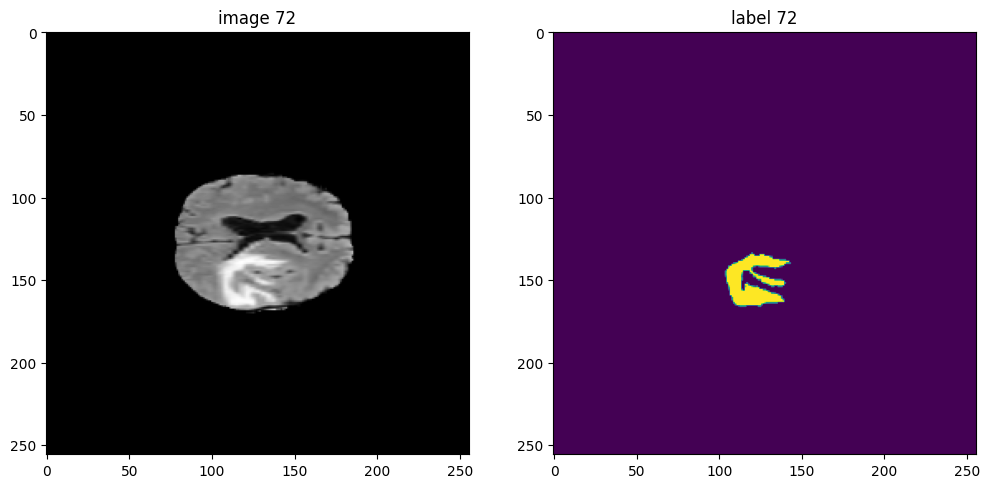

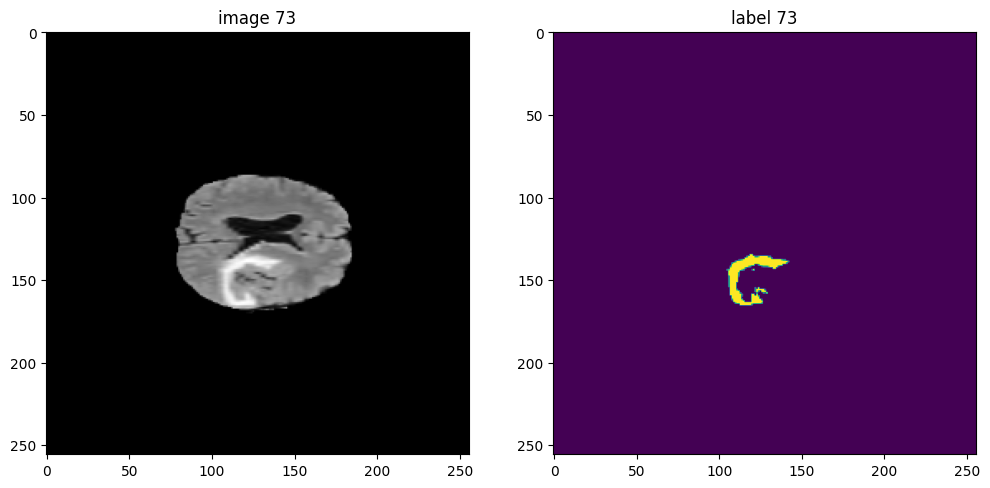

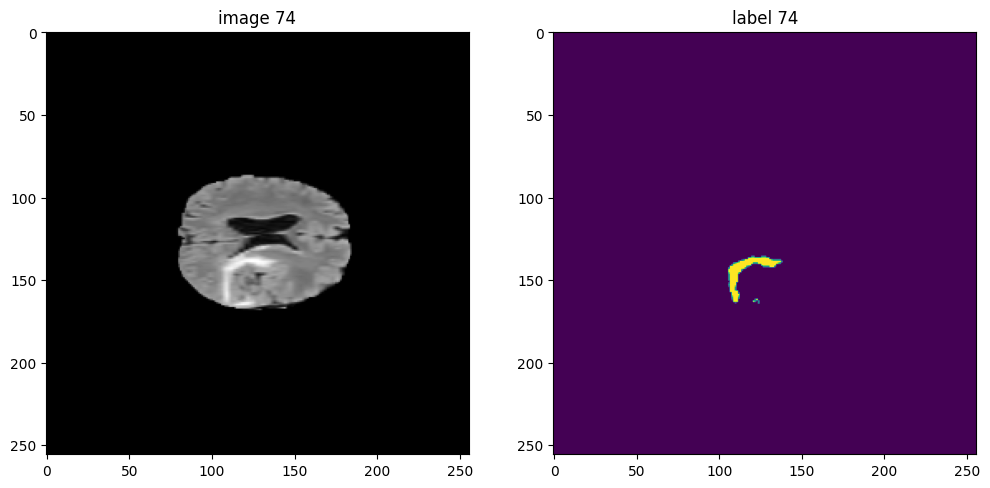

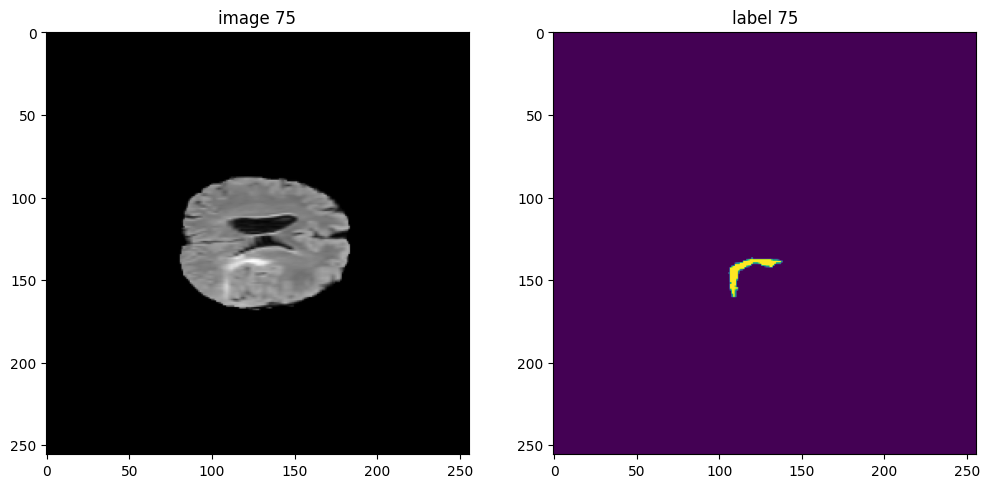

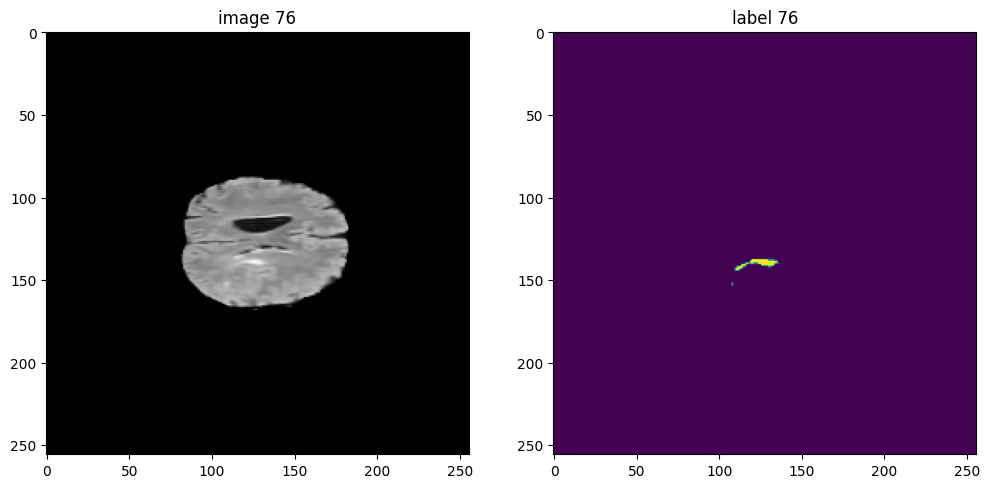

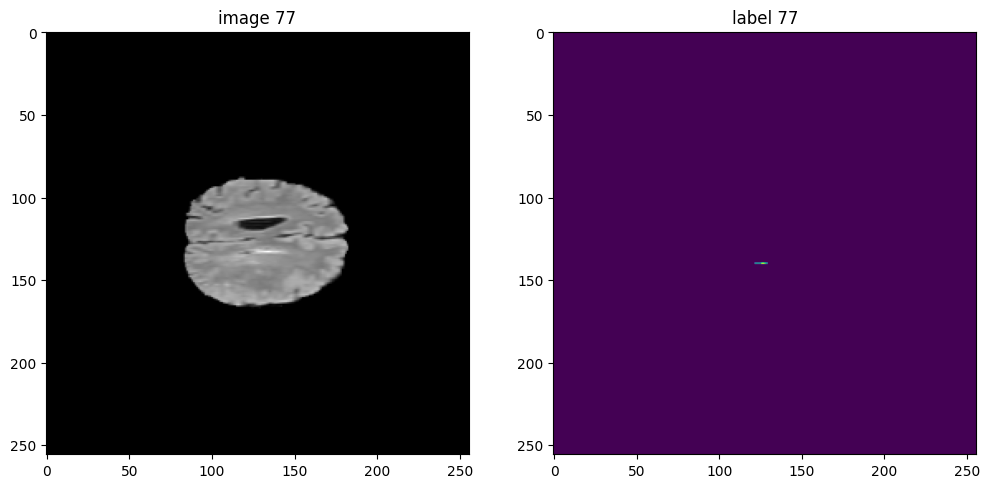

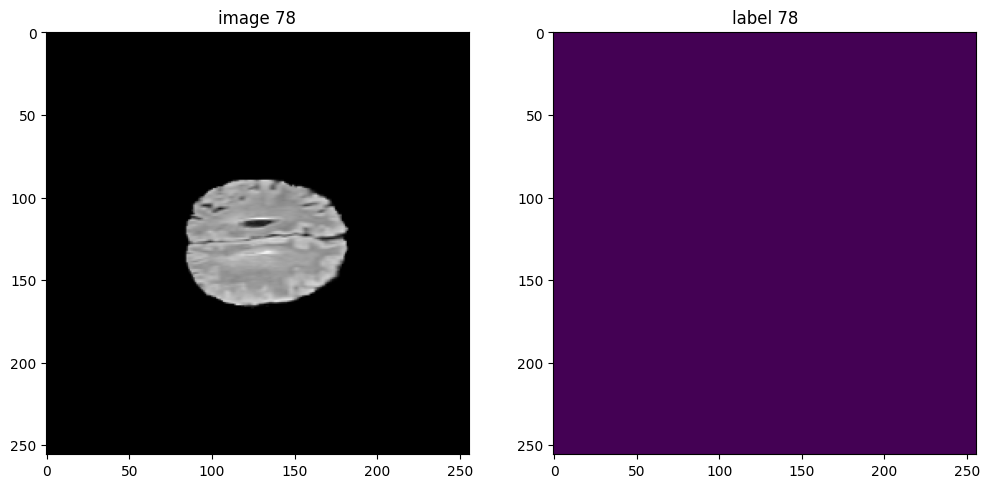

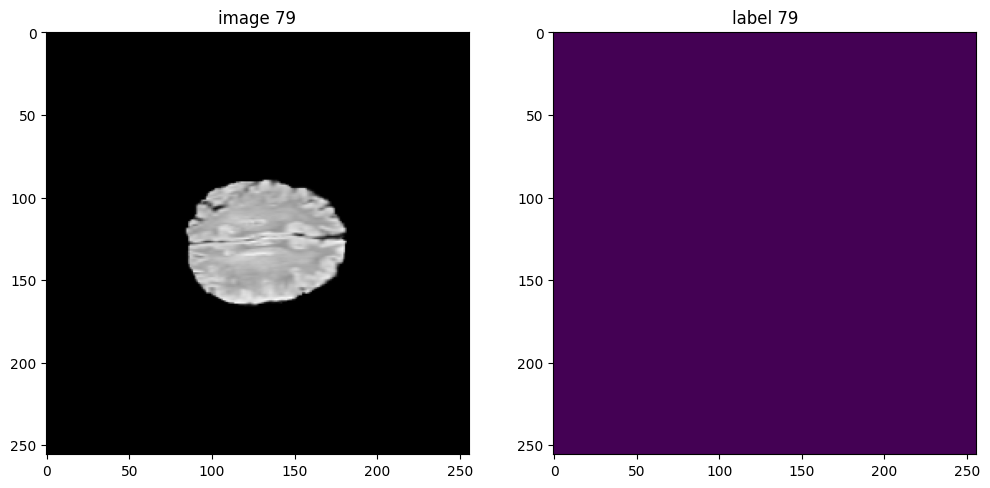

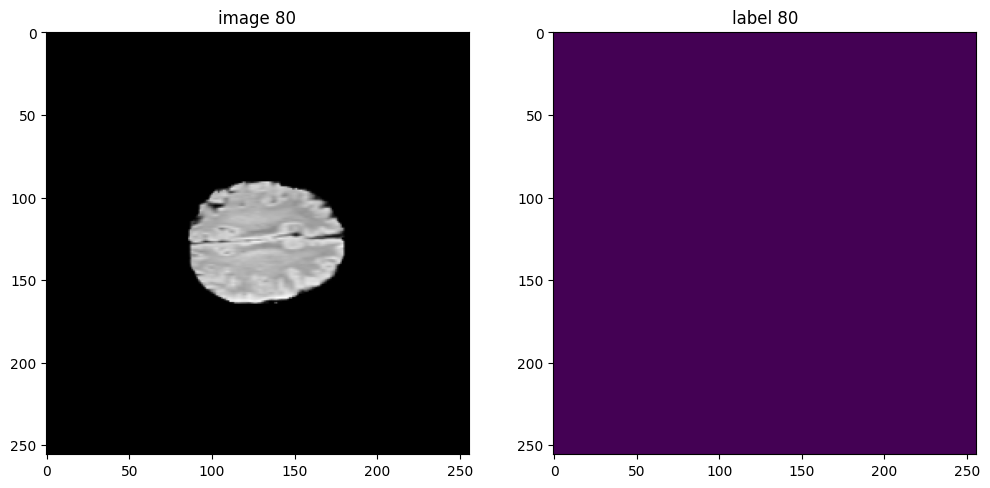

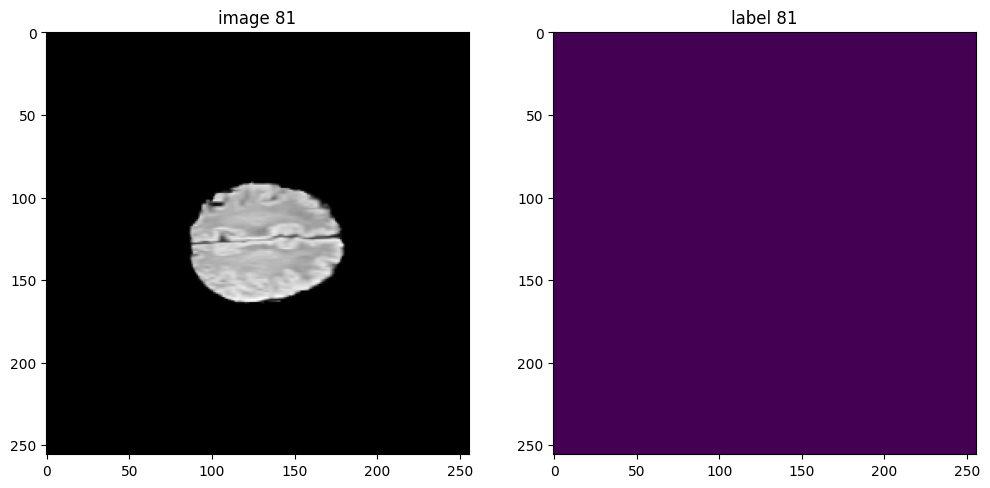

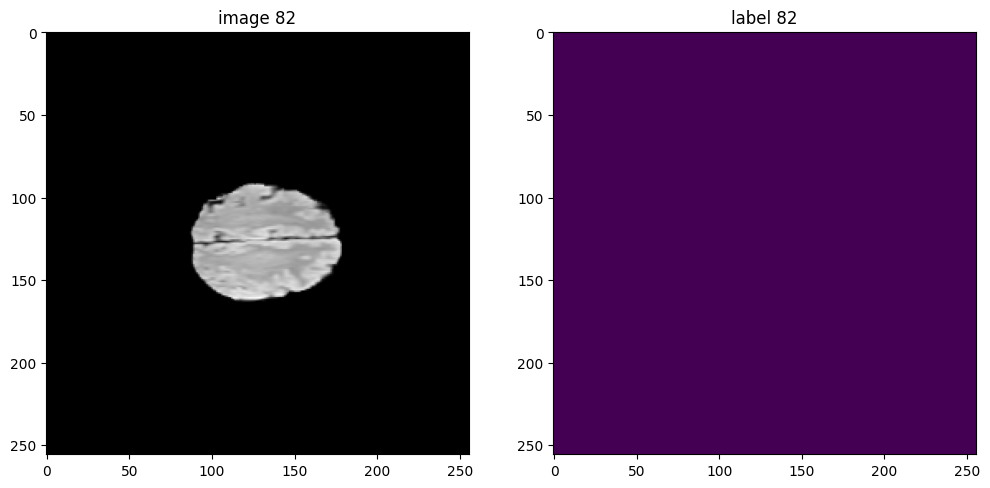

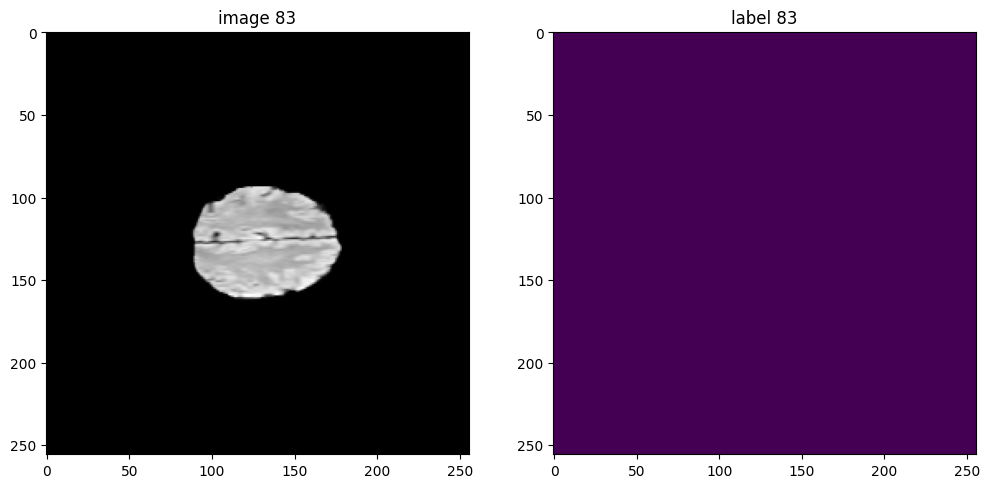

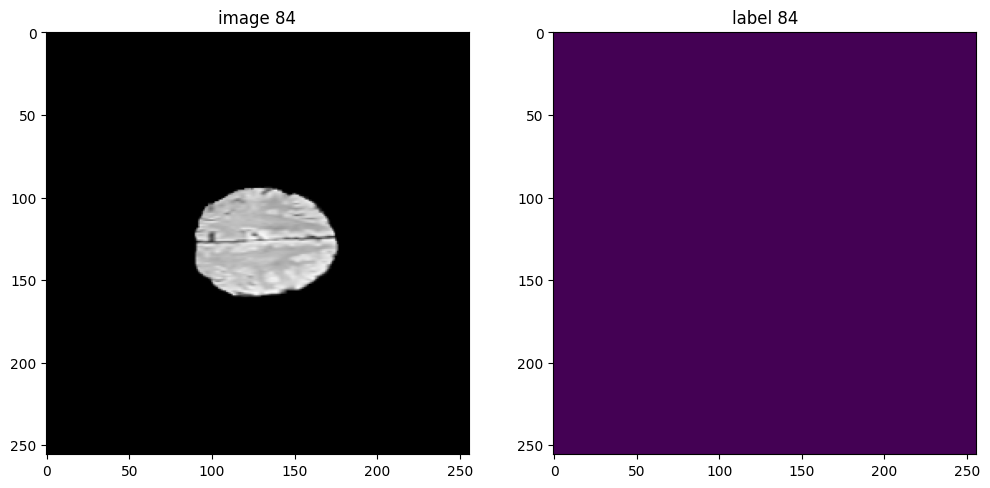

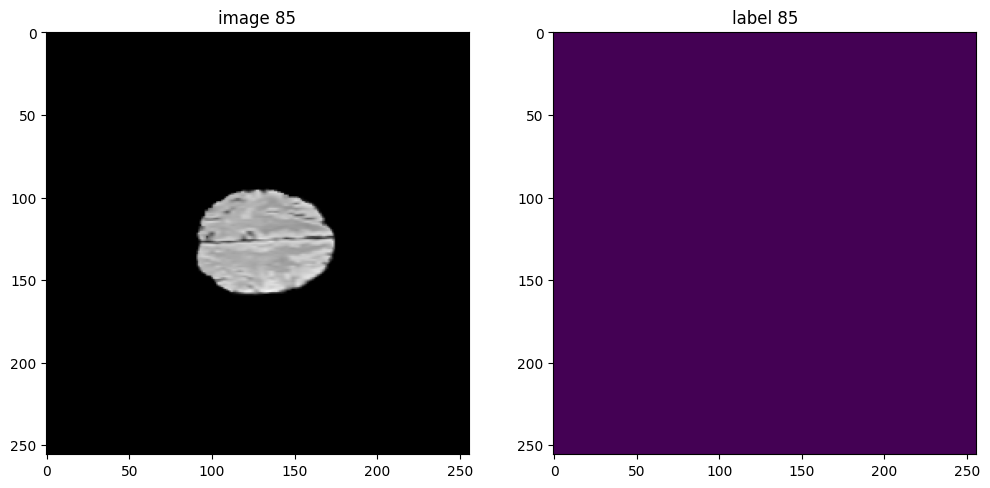

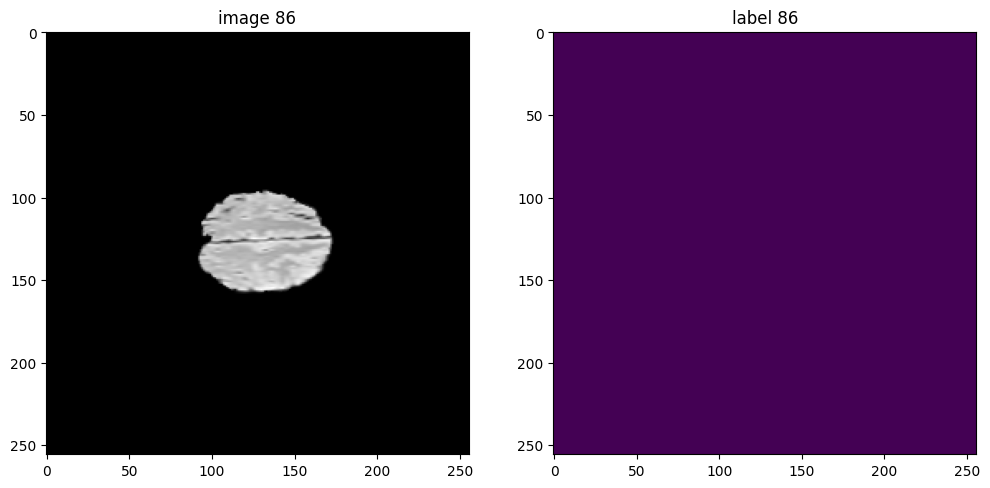

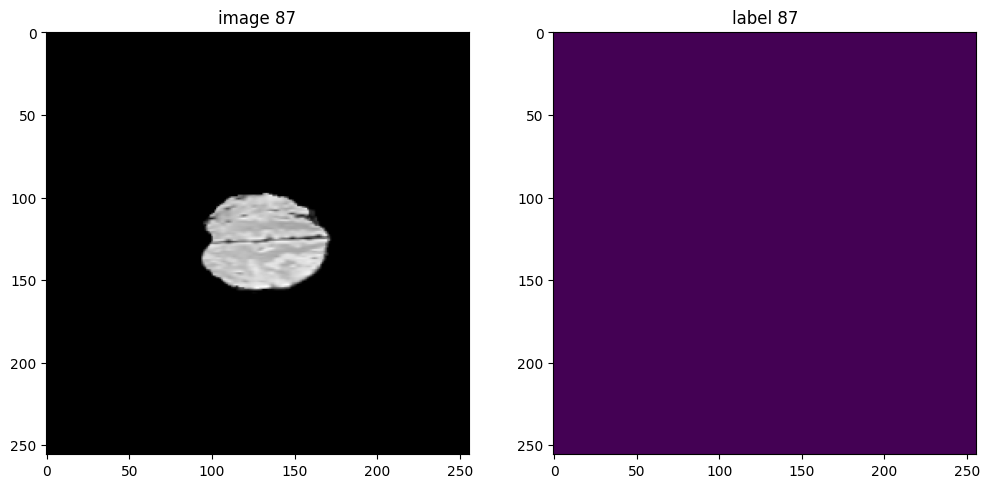

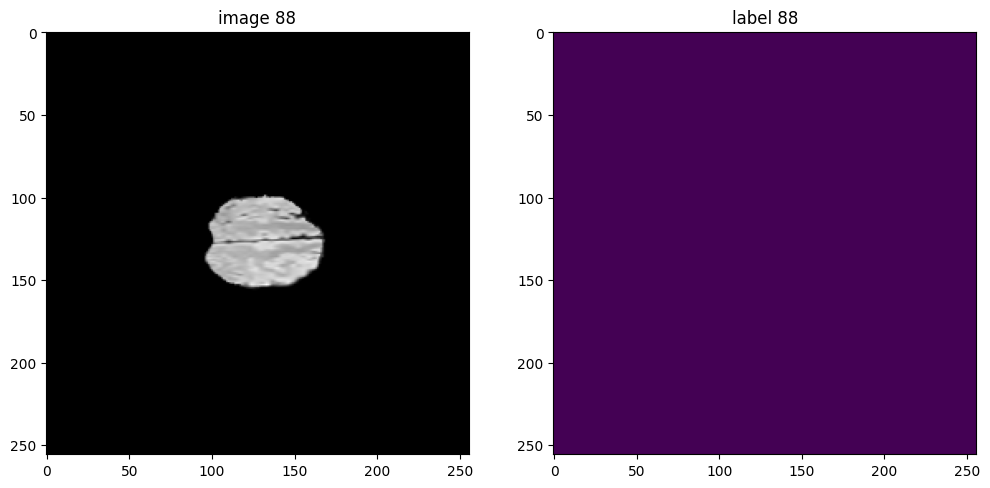

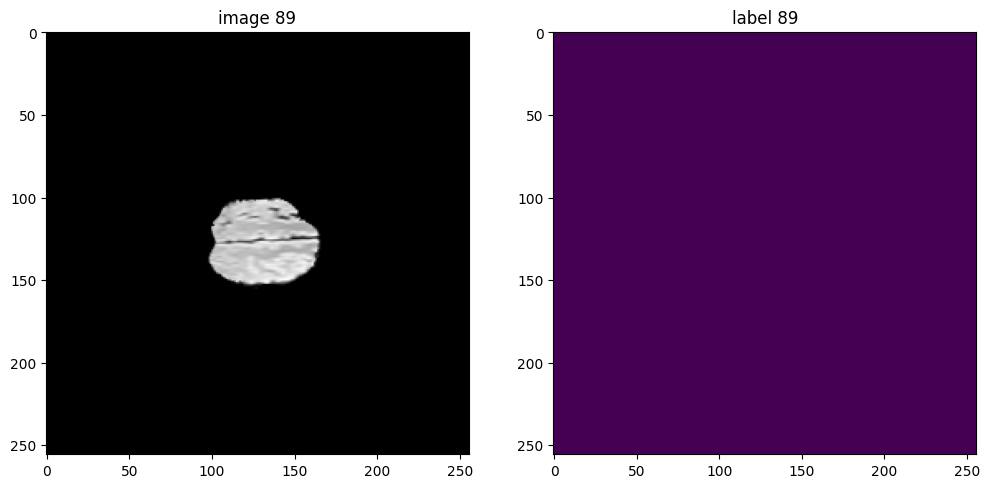

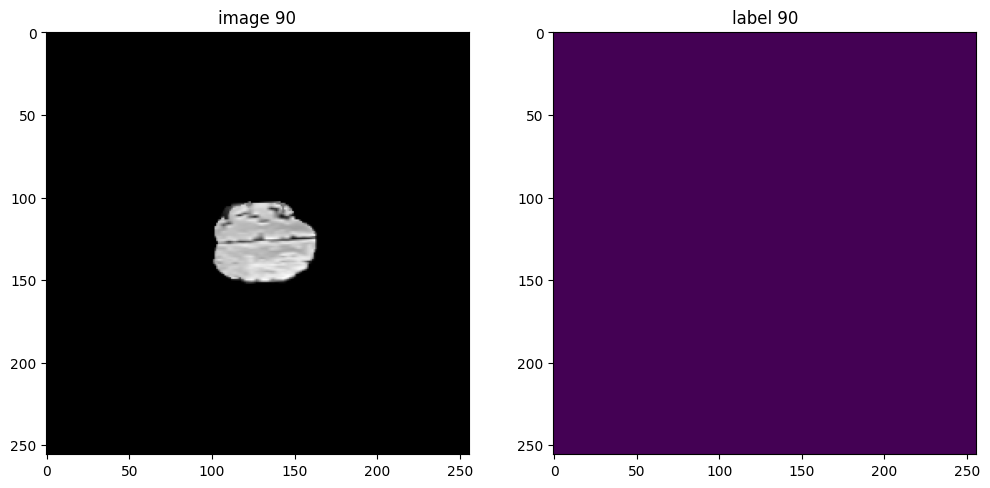

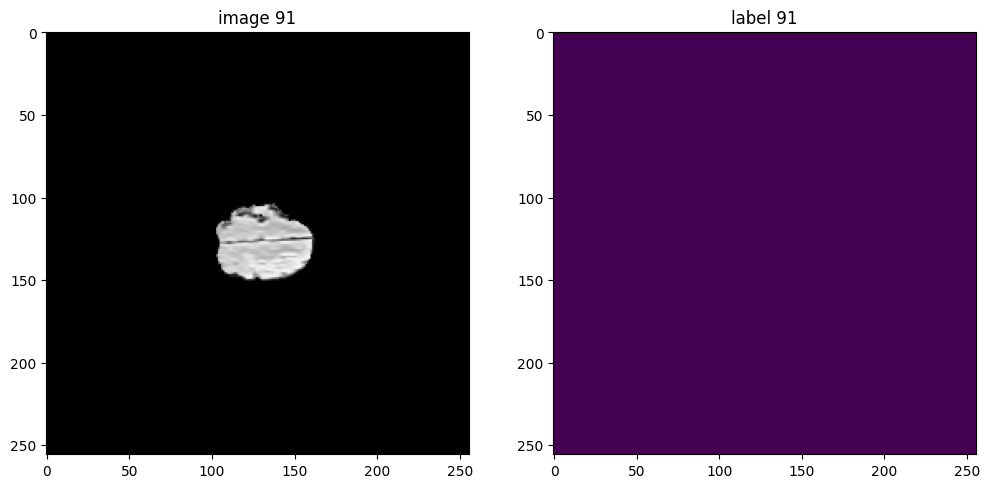

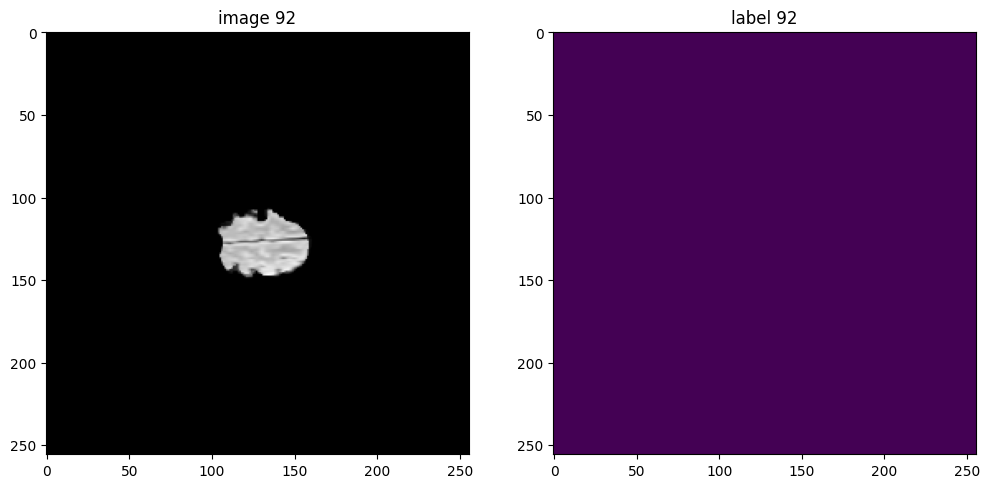

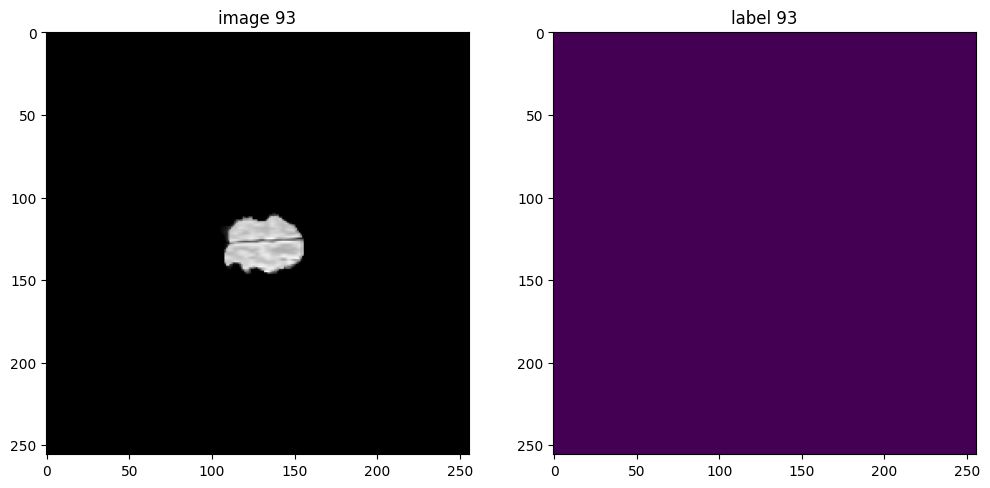

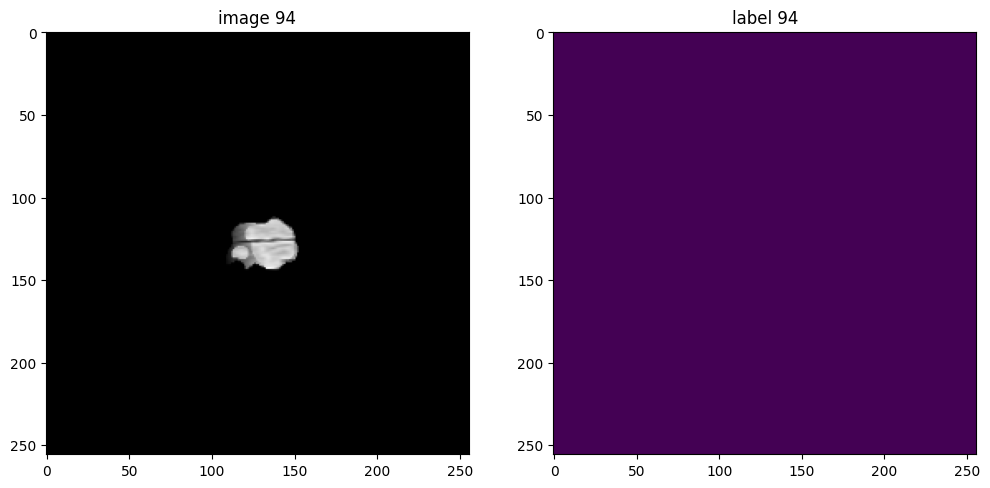

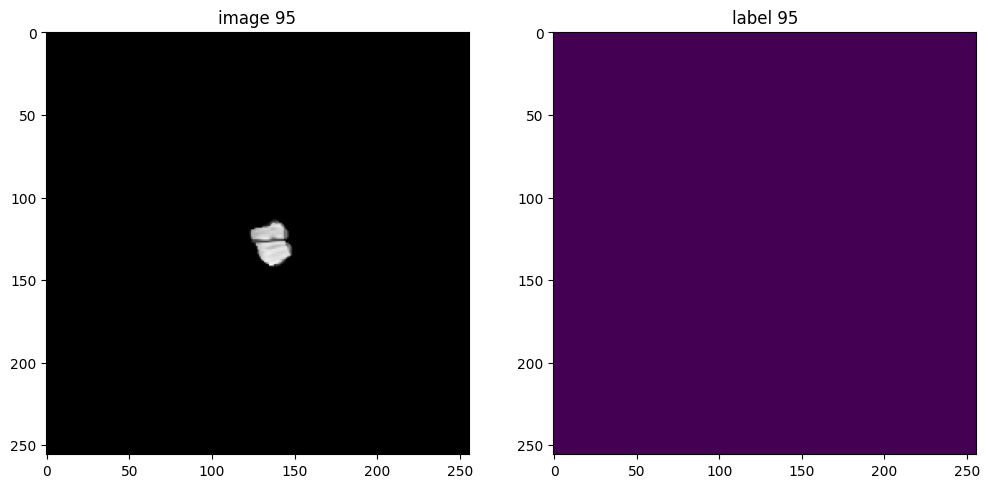

In [134]:
in_dir = 'D:/BrainDataset'
patient = prepare2(in_dir)
for i in range(30,96):
    show_patient(patient, i)